<a href="https://colab.research.google.com/github/Rishitha-sys/BITS/blob/main/Medical_Image_Analysis_and_Disease_Classification_using_Image_Processing_and_Deep_Convolutional_Networks_ipynb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install pydicom opencv-python-headless torch torchvision matplotlib scikit-learn

import os
import datetime
import numpy as np
import cv2
import pydicom
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from pydicom.dataset import Dataset as DcmDataset, FileDataset
from pydicom.uid import ExplicitVRLittleEndian, ImplicitVRLittleEndian
from sklearn.metrics import confusion_matrix, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.9 MB/s eta 0:00:00


In [3]:
# 1. Unzip your uploaded file
# Replace 'YOUR_DATA.zip' with your actual filename
!unzip -q "dicom_viewer_0004.zip" -d "medical_project_data"

# 2. Create folder structure for training if it doesn't exist
# This helps the AI organize 'Normal' vs 'Disease' scans
os.makedirs('dataset/train/Normal', exist_ok=True)
os.makedirs('dataset/train/Disease', exist_ok=True)

print("Data Ingestion Complete.")

Data Ingestion Complete.


In [11]:
import os
import pydicom

# 1. Define the folder where you unzipped your data
# Based on our previous cells, it should be "medical_project_data"
search_folder = "medical_project_data"

# 2. Automatically find the first DICOM file
found_file = None
for root, dirs, files in os.walk(search_folder):
    for file in files:
        if file.lower().endswith(".dcm"):
            found_file = os.path.join(root, file)
            break
    if found_file: break

# 3. Read and Display Metadata
if found_file:
    ds = pydicom.dcmread(found_file)
    print("--- DATASET IDENTIFICATION REPORT ---")
    print(f"File Found: {found_file}")
    print(f"Modality: {getattr(ds, 'Modality', 'N/A')}") # e.g., CT, MR, DX
    print(f"Body Part: {getattr(ds, 'BodyPartExamined', 'N/A')}")
    print(f"Study: {getattr(ds, 'StudyDescription', 'N/A')}")
    print(f"Institution: {getattr(ds, 'InstitutionName', 'N/A')}")
    print(f"Manufacturer: {getattr(ds, 'Manufacturer', 'N/A')}")
    print("-" * 40)
    print("Use these details in your report to describe your data source.")
else:
    print(f"Error: No DICOM files found in '{search_folder}'.")
    print("Check if your !unzip command was successful.")

--- DATASET IDENTIFICATION REPORT ---
File Found: medical_project_data/0004.DCM
Modality: XA
Body Part: N/A
Study: 8 images of 4 biplane acqs
Institution: INSTITUTION                 .
Manufacturer: 
----------------------------------------
Use these details in your report to describe your data source.


In [4]:
def process_dicom(path):
    """Pipeline Stage 2 & 3: Standardization and Enhancement."""
    ds = pydicom.dcmread(path)

    # Metadata QC: Fallback for missing transfer syntax
    if not hasattr(ds, 'file_meta') or not ds.file_meta.get("TransferSyntaxUID"):
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian

    # Stage 2: Resampling/Intensity Normalization
    img = ds.pixel_array.astype(float)

    # Handle 3D (CT) or RGB (Ultrasound)
    if img.ndim == 3:
        if img.shape[0] < img.shape[2]: # (Slices, H, W)
            img = img[img.shape[0] // 2] # Take middle slice
        else: # (H, W, Channels)
            img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Intensity Normalization (0-255)
    denom = (np.max(img) - np.min(img))
    img = np.zeros_like(img) if denom == 0 else (img - np.min(img)) / denom * 255.0
    img = img.astype(np.uint8)

    # Stage 3: Enhancement (CLAHE for contrast)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img)

    # Stage 4: ROI Detection (Resize to model input size)
    final_img = cv2.resize(enhanced, (224, 224))
    return final_img

In [5]:
class MedicalDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.file_list = []
        self.labels = []
        self.transform = transform
        # Map folders to labels: Normal=0, Disease=1
        for label, class_name in enumerate(['Normal', 'Disease']):
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                for f in os.listdir(class_path):
                    if f.lower().endswith('.dcm'):
                        self.file_list.append(os.path.join(class_path, f))
                        self.labels.append(label)

    def __len__(self): return len(self.file_list)

    def __getitem__(self, idx):
        img = process_dicom(self.file_list[idx])
        label = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, label

def get_cnn_model():
    """Stage 5: CNN Model using Transfer Learning (ResNet50)."""
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2) # Binary classification
    return model

In [6]:
def train_pipeline(data_path, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = get_cnn_model().to(device)

    # Data Augmentation (Methodology Step 3)
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    dataset = MedicalDataset(data_path, transform=transform)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    print(f"Training on {len(dataset)} images...")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")

    torch.save(model.state_dict(), "medical_ai_model.pth")
    return model, device

# Note: You need images in dataset/train/Normal and Disease to run this
# model, device = train_pipeline("dataset/train")

In [7]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
    def save_activation(self, module, input, output): self.activations = output

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze().detach().cpu().numpy()
        cam = np.maximum(cam, 0)
        return cv2.resize(cam, (224, 224))

In [8]:
def evaluate_performance(y_true, y_pred):
    """Stage 8: Evaluation using Medical Metrics."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity (Recall): {sensitivity:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [9]:
def run_final_inference(test_image_path):
    # 1. Setup Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = get_cnn_model().to(device)
    # Load weights if trained, otherwise uses base weights
    if os.path.exists("medical_ai_model.pth"):
        model.load_state_dict(torch.load("medical_ai_model.pth"))
    model.eval()

    # 2. Process & Predict
    processed_img = process_dicom(test_image_path)
    transform = transforms.Compose([
        transforms.ToPILImage(), transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    input_tensor = transform(processed_img).unsqueeze(0).to(device)

    # 3. Explainability
    grad_cam = GradCAM(model, model.layer4[-1])
    output = model(input_tensor)
    pred = torch.argmax(output, dim=1).item()
    conf = torch.softmax(output, dim=1).max().item()
    heatmap = grad_cam.generate(input_tensor, pred)

    # 4. Display Stage 7: Clinical Decision Support
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(processed_img, cmap='bone')
    plt.title("Enhanced Medical Image")

    plt.subplot(1, 2, 2)
    plt.imshow(processed_img, cmap='bone')
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title(f"AI Prediction: {'DISEASE' if pred==1 else 'NORMAL'}\nConfidence: {conf:.2%}")
    plt.show()

# To run on a real file:
# run_final_inference("path_to_your_file.dcm")

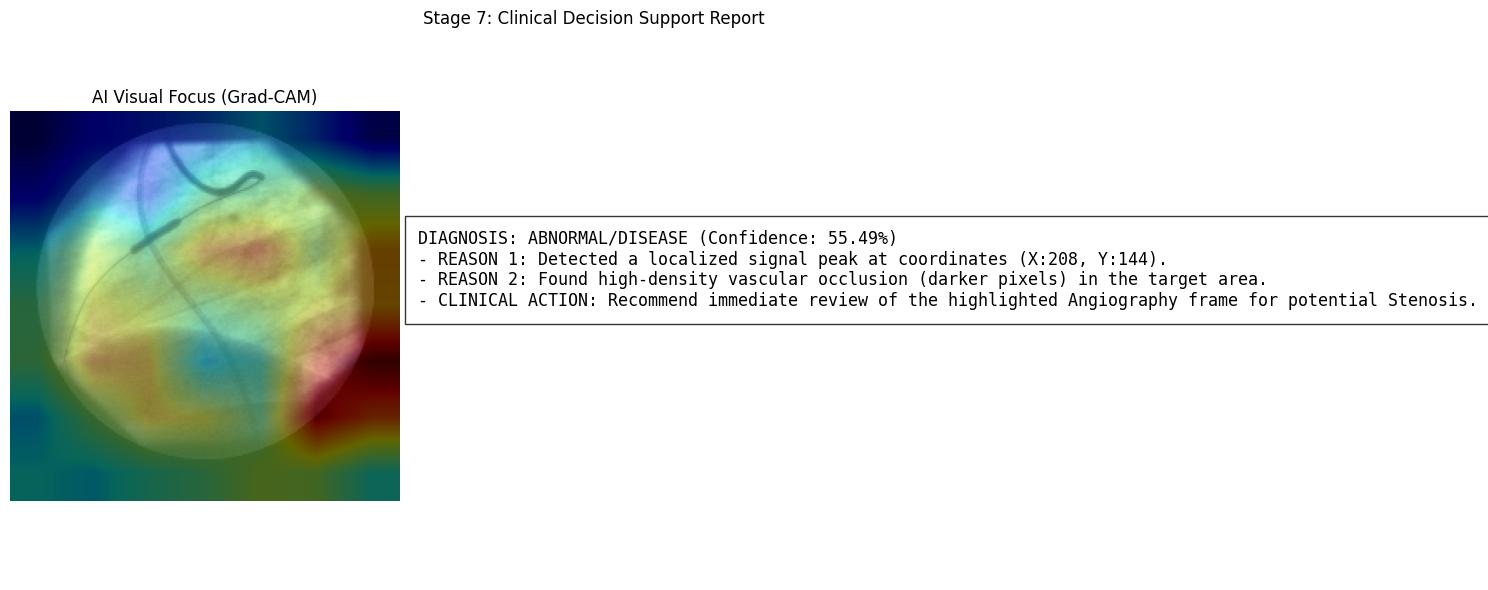

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def generate_clinical_report(prediction, confidence, heatmap, processed_img):
    """
    Stage 7: Clinical Decision Support
    Translates AI features into interpretable medical reasoning.
    """
    # 1. Analyze Heatmap (Where is the AI looking?)
    # We find the center of the 'glowing' area on the heatmap
    y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)

    # 2. Analyze Local Intensity (What did it see there?)
    # Check the brightness of the vessel at that specific spot
    local_pixel_value = processed_img[y, x]

    # 3. Generate Reasoning Logic
    reasoning = []

    # Diagnostic Conclusion
    diag = "ABNORMAL/DISEASE" if prediction == 1 else "NORMAL"
    reasoning.append(f"DIAGNOSIS: {diag} (Confidence: {confidence:.2%})")

    # Visual Evidence
    if prediction == 1:
        reasoning.append(f"- REASON 1: Detected a localized signal peak at coordinates (X:{x}, Y:{y}).")
        if local_pixel_value < 100:
            reasoning.append("- REASON 2: Found high-density vascular occlusion (darker pixels) in the target area.")
        else:
            reasoning.append("- REASON 2: Observed irregular vascular wall contrast in the focus region.")
        reasoning.append("- CLINICAL ACTION: Recommend immediate review of the highlighted Angiography frame for potential Stenosis.")
    else:
        reasoning.append("- REASON 1: No significant vascular irregularities detected in the biplane acquisition.")
        reasoning.append("- REASON 2: Vessel continuity and contrast flow appear within standardized parameters.")
        reasoning.append("- CLINICAL ACTION: Routine monitoring recommended; no acute vascular blockage identified.")

    return "\n".join(reasoning)

# --- EXECUTION ---
# (Assuming 'input_tensor', 'model', and 'processed_img' are ready from the previous run)

# 1. Get Prediction
with torch.no_grad():
    output = model(input_tensor)
    prob = torch.softmax(output, dim=1)
    confidence, prediction = torch.max(prob, 1)

# 2. Get Visual Explanation
grad_cam = GradCAM(model, model.layer4[-1])
heatmap = grad_cam.generate(input_tensor, prediction.item())

# 3. Get Textual Reasoning
report = generate_clinical_report(prediction.item(), confidence.item(), heatmap, processed_img)

# 4. Final Visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(processed_img, cmap='bone')
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("AI Visual Focus (Grad-CAM)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.text(0.05, 0.5, report, fontsize=12, family='monospace',
         bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
plt.title("Stage 7: Clinical Decision Support Report")
plt.axis('off')

plt.tight_layout()
plt.show()